# 6 · From spikes to a continuous signal

**What you will do:** convolve spike trains with a kernel to get continuous traces, narrow the design matrix, and read the digit out with ordinary linear and ridge regression.

**What you should take away:** the filter time constant is bin width made continuous; pooling channels and selecting channels destroy different things; and once you have continuous signals, "decoding" is regression on a matrix whose shape you should be able to state from memory.

Runtime: three to four minutes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from compbio2026 import data, decoding, filters, plotting

plotting.apply_style()
rng = np.random.default_rng(2026)

shd = data.load("train")
subset = rng.choice(np.flatnonzero(shd.english_mask()), size=800, replace=False)

DT = 4.0        # ms per bin
N_BANDS = 100   # width of the reduced design matrix, for both pooling and selection

X, y, t = data.build_design_matrix(shd, bin_ms=DT, t_max_ms=800.0, trials=subset)

print(f"X  {X.shape}   (trials, channels, bins) of spike counts")
print(f"y  {y.shape}   integer labels, values {sorted(set(y.tolist()))}")
print(f"t  {t.shape}   bin centres in ms, {t[0]:.1f} to {t[-1]:.1f}")

X  (800, 700, 200)   (trials, channels, bins) of spike counts
y  (800,)   integer labels, values [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
t  (200,)   bin centres in ms, 2.0 to 798.0


## What the binning already cost you

`build_design_matrix` is the only thing in this package that bins. Before it — `shd.times[i]`, `shd.units[i]`, `data.events` — you have the raw event list. After it, everything is quantised to `DT`.

Two properties of the raw data decide how much that matters.

Spike times are stored in the HDF5 file as **float16 seconds**, and float16 has no fixed grid: the gap between representable values grows with the value. Timing precision therefore degrades through the trial, from about 0.008 ms at 10 ms to 0.49 ms at 700 ms. That is a storage floor, not the resolution of the model that generated the data.

The smallest interval within one channel anywhere in the training set is **1.22 ms** — the refractory floor of the bushy-cell model. Nothing in SHD fires faster.

In [2]:
rows = []
for bw in [1.0, 2.0, 4.0, 10.0, 25.0]:
    Xb_, _, _ = data.build_design_matrix(shd, bin_ms=bw, t_max_ms=800.0, trials=subset[:200])
    occ = Xb_ > 0
    rows.append({"bin_ms": bw,
                 "features": int(np.prod(Xb_.shape[1:])),
                 "occupied cells with >1 spike (%)": 100 * (Xb_ > 1).sum() / occ.sum(),
                 "spikes lost by binarising (%)": 100 * (Xb_.sum() - occ.sum()) / Xb_.sum()})
pd.DataFrame(rows).set_index("bin_ms").round(2)

,features,occupied cells with >1 spike (%),spikes lost by binarising (%)
bin_ms,,,
1.0,560000,0.00,0.00
2.0,280000,0.08,0.08
4.0,140000,2.01,1.97
10.0,56000,25.10,21.64
25.0,22400,56.56,51.08


So `bin_ms` also decides what kind of object you have. At 1 ms the design matrix is the spike train written as a binary array, and `data.binarize(X)` is a no-op that will tell you so. At 4 ms, used here, about 2 % of occupied cells hold two or three spikes. By 25 ms most of them do, and calling it a raster would be wrong.

The standard dataloaders do not make this choice for you either. Zenke's `sparse_data_generator_from_hdf5_spikes` in the [spytorch](https://github.com/fzenke/spytorch) tutorials uses `time_bins = np.linspace(0, 1.4, num=100)` — 14.1 ms bins — and builds a sparse tensor of ones that coalesces by *summing* duplicates, so it is a count tensor commonly treated as binary. [tonic](https://tonic.readthedocs.io/) hands you the events and makes you pick the bin. You choose the width that makes the matrix binary; nothing hands it to you.

In [3]:
# Binarising at the bin width used below, and being told what it cost.
Xbin = data.binarize(X)

binarize: 136411/6054186 occupied cells held >1 spike (2.25 %); 136684 of 6190870 spikes discarded


## The three kernels

All three are normalised to unit area, so they preserve total spike count and differ only in *how they spread it in time*.

The right-hand panel plots the spikes twice: the recorded event times from `data.events`, and the binned version the filter actually sees. Every tick in the lower row sits at a bin centre, and where two spikes shared a bin only one survives. A "raster" drawn from a design matrix is a picture of bin occupancy.

channel 666: 22 recorded spikes -> 21 occupied bins (1 lost to collisions), each moved to its bin centre


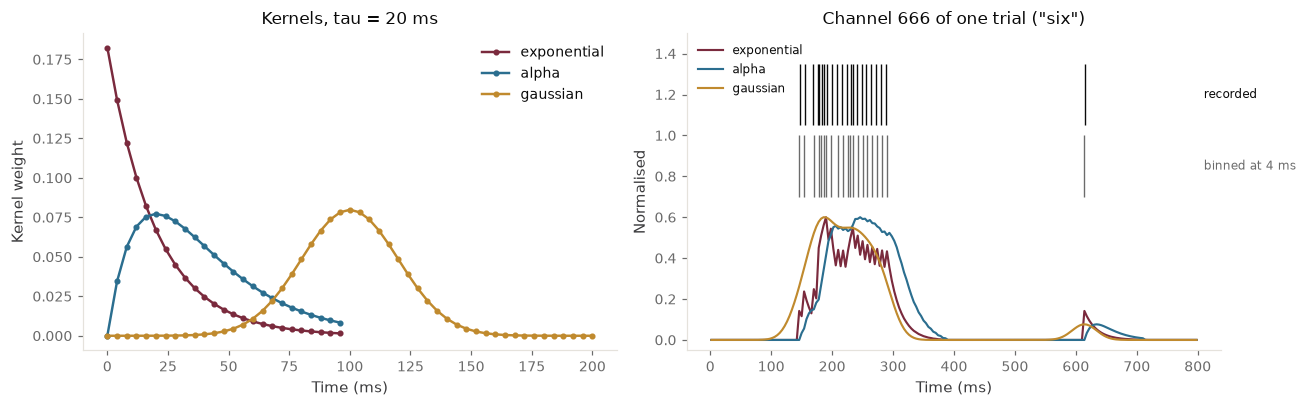

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

for kind in ["exponential", "alpha", "gaussian"]:
    k = filters.kernel(kind, tau_ms=20.0, dt_ms=DT)
    axes[0].plot(np.arange(len(k)) * DT, k, marker="o", ms=3, label=kind)
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Kernel weight")
axes[0].set_title("Kernels, tau = 20 ms")
axes[0].legend()

trial = 0
chan = int(X[trial].sum(axis=1).argmax())      # the busiest channel of this trial
ev = data.events(shd, subset[trial], t_max_ms=800.0)
true_times = ev[ev[:, 0] == chan, 1]                    # ms, as recorded
binned = t[X[trial, chan] > 0]                          # bin centres of occupied bins

axes[1].vlines(true_times, 1.05, 1.35, color=plotting.INK, lw=0.9)
axes[1].vlines(binned, 0.70, 1.00, color=plotting.INK_MUTED, lw=0.9)
axes[1].text(810, 1.20, "recorded", fontsize=8, color=plotting.INK, va="center")
axes[1].text(810, 0.85, f"binned at {DT:.0f} ms", fontsize=8, color=plotting.INK_MUTED, va="center")
for kind in ["exponential", "alpha", "gaussian"]:
    f = filters.filter_spikes(X[trial:trial + 1, chan:chan + 1], kind, tau_ms=20.0, dt_ms=DT)[0, 0]
    axes[1].plot(t, f / f.max() * 0.6, lw=1.4, label=kind)
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Normalised")
axes[1].set_ylim(-0.05, 1.5)
axes[1].set_title(f'Channel {chan} of one trial ("{data.DIGIT_KEYS[y[trial]]}")')
axes[1].legend(fontsize=8, loc="upper left")
fig.tight_layout()
plotting.savefig(fig, "06_kernels", outdir="../plots")

print(f"channel {chan}: {len(true_times)} recorded spikes -> {len(binned)} occupied bins "
      f"({len(true_times) - len(binned)} lost to collisions), each moved to its bin centre")

Note where each trace sits relative to the spikes.

- **Exponential** jumps at the spike and decays. Causal.
- **Alpha** rises then falls, so its peak *lags* the spike by about `tau`. Causal, and the closest of the three to a real postsynaptic potential.
- **Gaussian** is symmetric, which means the signal starts rising *before* the spike. That is fine for offline analysis and wrong for anything claiming to be a mechanism — a synapse cannot anticipate.

## The population, before and after

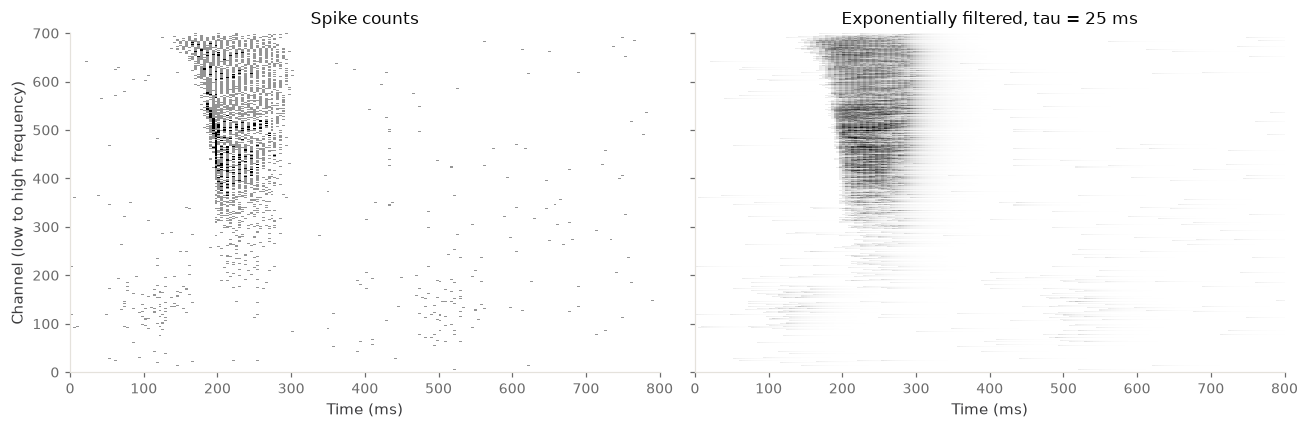

In [5]:
F = filters.filter_spikes(X, "exponential", tau_ms=25.0, dt_ms=DT)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].imshow(X[trial], aspect="auto", origin="lower", cmap="Greys",
               extent=[0, 800, 0, X.shape[1]], interpolation="nearest")
axes[0].set_title("Spike counts")
axes[1].imshow(F[trial], aspect="auto", origin="lower", cmap="Greys",
               extent=[0, 800, 0, X.shape[1]], interpolation="nearest")
axes[1].set_title("Exponentially filtered, tau = 25 ms")
for ax in axes:
    ax.set_xlabel("Time (ms)")
axes[0].set_ylabel("Channel (low to high frequency)")
fig.tight_layout()

## Making the matrix narrower: two different operations

At 4 ms bins the design matrix is 700 × 200 = 140 000 features per trial. Ridge on that is a 140 000-column dense solve inside every cross-validation fold, and the notebook stops being usable. Something has to give, and there are two ways to give it.

`filters.pool_channels(X, 100)` **averages** groups of seven adjacent channels into 100 bands. Channel index is tonotopic, so this averages over a frequency band rather than over arbitrary neurons, and every spike still contributes. What goes is identity: a band is a mixture, so a weight on it is a statement about a frequency range.

`filters.select_channels(X, 100)` **keeps** 100 whole channels and discards the other 600. Every retained column is one bushy cell, which is what you need for anything about receptive fields, ablation, or "which neurons matter". What goes is coverage: six of every seven spikes.

Pick the one whose failure mode fits the claim you intend to make, and check what it cost.

In [6]:
Xb = filters.pool_channels(X, N_BANDS)
Xs, kept = filters.select_channels(X, N_BANDS, method="uniform")

print(f"X   {X.shape}  -> {int(np.prod(X.shape[1:])):>6d} features per trial")
print(f"Xb  {Xb.shape}  -> {int(np.prod(Xb.shape[1:])):>6d}   pooled: 7 channels averaged per band")
print(f"Xs  {Xs.shape}  -> {int(np.prod(Xs.shape[1:])):>6d}   selected: channels {kept[:4]} ... {kept[-2:]}")
print()
print(f"spikes still represented:  pooling {filters.pool_channels(X, N_BANDS, reduce='sum').sum() / X.sum():.0%}"
      f"   selection {Xs.sum() / X.sum():.0%}")

X   (800, 700, 200)  -> 140000 features per trial
Xb  (800, 100, 200)  ->  20000   pooled: 7 channels averaged per band
Xs  (800, 100, 200)  ->  20000   selected: channels [ 0  7 14 21] ... [692 699]



spikes still represented:  pooling 100%   selection 14%


In [7]:
# What each reduction costs, measured rather than assumed.
rows = [{"matrix": "full, 700 channels", "features": int(np.prod(X.shape[1:])),
         "accuracy": decoding.decode(data.flatten(F), y,
                                     estimator=decoding.make_readout("ridge"))["mean"]}]
for name, M in [("pooled to 100 bands", Xb), ("100 selected channels", Xs)]:
    Ff = data.flatten(filters.filter_spikes(M, "exponential", tau_ms=25.0, dt_ms=DT))
    rows.append({"matrix": name, "features": Ff.shape[1],
                 "accuracy": decoding.decode(Ff, y, estimator=decoding.make_readout("ridge"))["mean"]})
rows.append({"matrix": "chance", "features": 0, "accuracy": decoding.chance_level(y)})
pd.DataFrame(rows).set_index("matrix").round(3)

/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.3456093007089294e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.335243192736925e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.338612231118532e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.2102949631962474e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.9049567135407415e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


,features,accuracy
matrix,,
"full, 700 channels",140000,0.866
pooled to 100 bands,20000,0.852
100 selected channels,20000,0.785
chance,0,0.115


Pooling loses less than selection at the same width, which is what a redundant code predicts: averaging seven correlated channels keeps most of their shared signal, while keeping one of seven throws six copies away. That argues for pooling if accuracy is all you want, and not at all if you intend to say something about individual cells.

The sections below use `Xb`, the pooled matrix, for the accuracy reason — so everything they conclude is about frequency bands.

## Reading the digit out with linear regression

The most literal version of "decode": regress **one-hot class targets** on the filtered activity and take the largest output as the prediction. This is the classic linear readout — the same object as a trained readout weight vector in a reservoir.

The next cell prints every array rather than describing it, because this is where the notebook is easiest to lose track of.

- `Xb` is `(800, 100, 200)` — 800 trials, 100 tonotopic bands, 200 bins of 4 ms.
- `Xf` is `Xb` filtered along time and **flattened** to `(800, 20 000)`. The flattening is channel-major, so column `k` is band `k // 200` at bin `k % 200`. One row is one trial's whole space–time activity as a vector, and the regression treats those 20 000 numbers as unrelated predictors; it does not know that some of them are neighbours in time.
- `y` is `(800,)` of integers, each the index of that trial's digit in `data.DIGIT_KEYS`, so `y[i] == 3` is the word "three". This subset comes from `english_mask()`, so the values run 0–9.
- `Y1h` is `(800, 10)`: row `i` is zeros except a 1 in the column for trial `i`'s digit. Regression cannot fit an integer label directly, since 0–9 carry an order and a scale the classes do not, so you fit ten regressions at once — one per class, each answering "is this trial that digit". `predict` returns ten numbers per trial and `argmax` picks the winner.

Build the one-hot by **rank**, not by raw label value. `np.eye(n_classes)[y]` indexes columns by the label itself and works only when the labels happen to be `0 … n_classes-1`; restrict to the German digits (10–19) and it raises `IndexError`. `np.unique(y, return_inverse=True)` gives the rank.

In [8]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

Xf = filters.filter_spikes(Xb, "exponential", tau_ms=25.0, dt_ms=DT).reshape(len(Xb), -1)

classes, y_rank = np.unique(y, return_inverse=True)   # rank, not raw label value
Y1h = np.eye(len(classes))[y_rank]

print(f"Xb   {Xb.shape}")
print(f"Xf   {Xf.shape}   column k = band k//{Xb.shape[2]} at bin k%{Xb.shape[2]}")
print(f"y    {y.shape}   e.g. y[:6] = {y[:6]} = {[data.DIGIT_KEYS[i] for i in y[:6]]}")
print(f"Y1h  {Y1h.shape}   e.g. Y1h[0] = {Y1h[0].astype(int)}  -> column {y_rank[0]} -> '{data.DIGIT_KEYS[classes[y_rank[0]]]}'")

Xb   (800, 100, 200)
Xf   (800, 20000)   column k = band k//200 at bin k%200
y    (800,)   e.g. y[:6] = [6 3 2 4 3 5] = ['six', 'three', 'two', 'four', 'three', 'five']
Y1h  (800, 10)   e.g. Y1h[0] = [0 0 0 0 0 0 1 0 0 0]  -> column 6 -> 'six'


In [9]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
rows = []
for name, model in [("linear regression", LinearRegression()),
                    ("ridge (alpha=1)", Ridge(alpha=1.0)),
                    ("ridge (alpha=1e3)", Ridge(alpha=1e3)),
                    ("ridge (alpha=1e5)", Ridge(alpha=1e5))]:
    accs = []
    for tr, te in cv.split(Xf, y):
        sc = StandardScaler().fit(Xf[tr])
        m = model.fit(sc.transform(Xf[tr]), Y1h[tr])
        pred = m.predict(sc.transform(Xf[te])).argmax(1)     # column index = class rank
        accs.append((pred == y_rank[te]).mean())
    rows.append({"model": name, "accuracy": np.mean(accs), "sd": np.std(accs)})

pd.DataFrame(rows).set_index("model").round(3)

,accuracy,sd
model,,
linear regression,0.852,0.024
ridge (alpha=1),0.852,0.024
ridge (alpha=1e3),0.864,0.025
ridge (alpha=1e5),0.811,0.038


Unregularised least squares does not collapse here, although 640 training trials against 20 000 columns says it should. `LinearRegression` solves with `lstsq`, which returns the **minimum-norm** solution among the infinitely many that fit the training data exactly, and minimum norm is itself a regulariser — the one ridge converges to as `alpha` goes to zero. Hence the first two rows agreeing to three decimals.

Ridge buys a little and then loses it: an optimum near `alpha = 1e3`, and by `1e5` the penalty flattens the useful structure along with the noise.

Pooling took the matrix from 140 000 columns to 20 000, and it is still thirty times wider than the training set is tall. The penalty — explicit in ridge, implicit in `lstsq` — is why any of these numbers are above chance.

## The filter time constant is the real knob

`tau` decides how much temporal detail survives — the same decision as bin width, made continuously.

/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1718839942886916e-07.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1595450644108496e-07.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


kernel,alpha,exponential
tau_ms,,
2.0,0.804,0.822
5.0,0.859,0.854
10.0,0.839,0.856
25.0,0.810,0.852
50.0,0.784,0.856
100.0,0.745,0.842
200.0,0.714,0.847


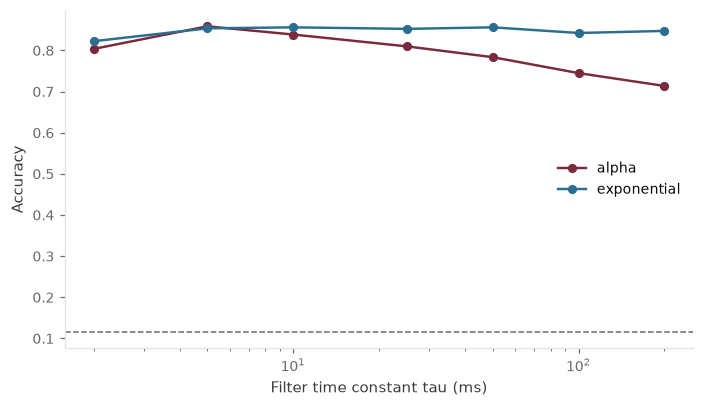

In [10]:
taus = [2.0, 5.0, 10.0, 25.0, 50.0, 100.0, 200.0]
rows = []
for kind in ["exponential", "alpha"]:
    for tau in taus:
        Ff = filters.filter_spikes(Xb, kind, tau_ms=tau, dt_ms=DT).reshape(len(Xb), -1)
        r = decoding.decode(Ff, y, estimator=decoding.make_readout("ridge"))
        rows.append({"kernel": kind, "tau_ms": tau, "accuracy": r["mean"]})
tau_sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for kind, grp in tau_sweep.groupby("kernel"):
    ax.plot(grp["tau_ms"], grp["accuracy"], marker="o", ms=5, label=kind)
ax.axhline(decoding.chance_level(y), ls="--", lw=1, color=plotting.INK_MUTED)
ax.set_xscale("log")
ax.set_xlabel("Filter time constant tau (ms)")
ax.set_ylabel("Accuracy")
ax.legend()
fig.tight_layout()
plotting.savefig(fig, "06_tau_sweep", outdir="../plots")

tau_sweep.pivot(index="tau_ms", columns="kernel", values="accuracy").round(3)

The two kernels behave differently. The alpha kernel has an optimum near 5 ms and falls away on both sides; the exponential is nearly flat from 5 ms to 200 ms.

That is because **this readout cannot lose much to a filter**. Convolution is a linear time-invariant map applied to the whole time course, the readout sees the whole time course, and a linear model can undo an invertible linear map. The exponential kernel is nonzero at lag zero, so its convolution matrix is triangular with a nonzero diagonal and invertible. The alpha kernel starts at zero at lag zero and has a rise time, which makes it far worse conditioned — and that is where its optimum comes from.

So `tau` is changing the conditioning of the design matrix, and therefore what the ridge penalty prefers, rather than the information available. Easy to misread as "the filter destroyed spike timing".

The filter genuinely *is* the memory in the next section, which reads out from a single instant.

## Reading out as the trial unfolds

Because the filtered signal is continuous, you can apply a readout **at every time step** rather than once per trial. This is what an online decoder would do.

best single-moment accuracy 0.450 at 282 ms


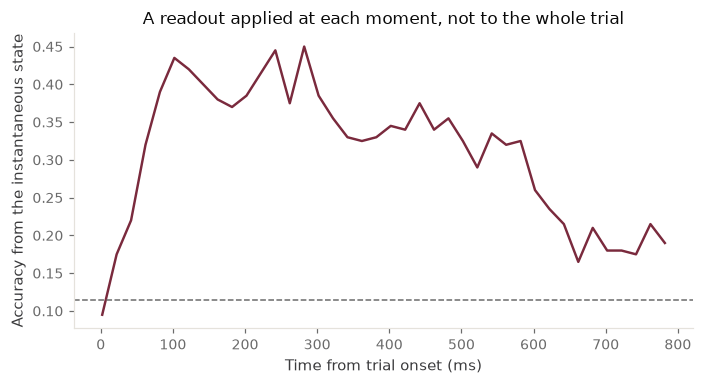

In [11]:
from sklearn.linear_model import RidgeClassifier
from sklearn.pipeline import make_pipeline

Ft = filters.filter_spikes(Xb, "exponential", tau_ms=25.0, dt_ms=DT)
idx_tr, idx_te = next(StratifiedKFold(4, shuffle=True, random_state=0).split(Ft, y))

step = 5
times, accs = [], []
for b in range(0, Ft.shape[2], step):
    clf = make_pipeline(StandardScaler(), RidgeClassifier(alpha=1e3))
    clf.fit(Ft[idx_tr, :, b], y[idx_tr])
    accs.append(clf.score(Ft[idx_te, :, b], y[idx_te]))
    times.append(t[b])

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(times, accs, color=plotting.ACCENT)
ax.axhline(decoding.chance_level(y), ls="--", lw=1, color=plotting.INK_MUTED)
ax.set_xlabel("Time from trial onset (ms)")
ax.set_ylabel("Accuracy from the instantaneous state")
ax.set_title("A readout applied at each moment, not to the whole trial")
fig.tight_layout()

print(f"best single-moment accuracy {max(accs):.3f} at {times[int(np.argmax(accs))]:.0f} ms")

Each point uses only the population state **at that instant** — 100 band values, no history beyond what the filter already carries. The rise is the filter integrating evidence; the fall is that evidence decaying once the word ends.

This is the sense in which the filter *is* the memory. Change `tau` and the shape of this curve changes with it.

---

## Exercises

1. **Match the readout to the kernel.** For each `tau`, find the best ridge `alpha` by nested cross-validation. Does the optimal `alpha` depend on `tau`, and why would it?
2. **Causality matters.** Redo the time-resolved readout with the Gaussian kernel. Accuracy will rise *before* the word starts. Explain precisely where that information came from.
3. **Pooling versus selection, properly.** Repeat the reduction table for `method="random"`, `"rate"` and `"variance"` in `select_channels`, and for `reduce="sum"` in `pool_channels`. Which comparison is the fair one, and does the ranking survive a change of `N_BANDS`?
4. **Per-channel time constants.** Nothing forces one `tau` for all 700 channels. Give low-frequency channels a longer one and see whether it helps.
5. **Regression rather than classification.** Instead of one-hot targets, regress a continuous variable — trial duration, or total spike count — and report R² instead of accuracy.
6. **Compare with binning.** For matched effective smoothing, does filtering beat plain binning? If not, what did the extra machinery buy?

Next: **[7 · Decoding in the projection](07_projections_and_clustering.ipynb)** — classifying inside an embedding, and what clustering finds there.